In [1]:
# --- CELLA 1: SETUP AMBIENTE E IMPORTAZIONI ---
import sys
import os
import yaml
import h5py
import numpy as np
import scipy.io as sio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# ========== GLOBAL SEED FOR REPRODUCIBILITY ==========
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'✅ Global seed set to {SEED} for reproducibility')
# =====================================================

PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)
print(f'Working dir: {os.getcwd()}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Setup completato! Stiamo usando: {device}')


✅ Global seed set to 42 for reproducibility
Working dir: /media/beegfs/home/y222/y222446/SpectraBreast
✅ Setup completato! Stiamo usando: cuda


In [2]:
# --- CELLA 2: LETTURA CONFIGURAZIONE E CREAZIONE SCONTRINO ---
import os
import yaml
import shutil

# Prende il config dalla shell lanciata da .sh, o default se lanciato a mano
config_file = os.environ.get('EXP_CONFIG_FILE', 'configs/classification/IBD/CNN/exp_01_cnn_baseline.yaml')

assert os.path.exists(config_file), f'Config non trovato: {config_file}'

with open(config_file, 'r') as f:
    config = yaml.safe_load(f)

split_seed = config.get('split', {}).get('seed', None)
if split_seed is not None:
    SEED = int(split_seed)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'✅ Seed da YAML attivo: {SEED}')

output_dir = config_file.replace('configs', 'experiments').replace('.yaml', '')
os.makedirs(output_dir, exist_ok=True)

shutil.copy(config_file, os.path.join(output_dir, 'config_usato.yaml'))

print(f"Esperimento in esecuzione: {config.get('experiment_name', 'unknown')}")
print(f'Config usato: {config_file}')
print(f'I risultati verranno salvati in:\n{output_dir}')


✅ Seed da YAML attivo: 42
Esperimento in esecuzione: exp_02_cnn_lomo
Config usato: configs/classification/Trophy/CNN/exp_01_cnn_lomo.yaml
I risultati verranno salvati in:
experiments/classification/Trophy/CNN/exp_01_cnn_lomo


In [3]:
# --- CELLA 3: CARICAMENTO DATI E CREAZIONE SPLIT CONGIUNTI ---
import os
import json
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from src.data.mat_loader import load_mat_dataset
from src.data.splits import make_holdout_split, make_kfold_splits, make_lomo_folds

ds_cfg = config.get('dataset', {})
dataset_path = ds_cfg.get('path')
print(f'Caricamento dati da: {dataset_path}...')

keys_cfg = ds_cfg.get('keys', {})
x_key = ds_cfg.get('x_key', keys_cfg.get('x'))
y_key = ds_cfg.get('y_key', keys_cfg.get('y'))
group_key = ds_cfg.get('group_key', keys_cfg.get('groups'))
axis_key = ds_cfg.get('axis_key', keys_cfg.get('axis'))
dataset_name = ds_cfg.get('name')

loaded = load_mat_dataset(
    dataset_path,
    x_key=x_key,
    y_key=y_key,
    group_key=group_key,
    axis_key=axis_key,
    dataset_name=dataset_name,
    keys=keys_cfg,
)
X_data, Y_data, x_axis, groups = loaded.X, loaded.y, loaded.x_axis, loaded.groups
N, L = X_data.shape

BATCH_SIZE = int(ds_cfg.get('batch_size', config.get('training', {}).get('batch_size', 32)))

split_cfg = config.get('split', {})
SPLIT_SEED = int(split_cfg.get('seed', SEED))

# -- 1) SETUP HOLDOUT
holdout_cfg = split_cfg.get('holdout', {})
test_size = float(holdout_cfg.get('test_size', 0.30))
val_size_of_temp = float(holdout_cfg.get('val_size_of_temp', 0.50))
split_ho = make_holdout_split(Y_data, seed=SPLIT_SEED, test_size=test_size, val_size_of_temp=val_size_of_temp)

train_loader_ho = DataLoader(TensorDataset(torch.from_numpy(X_data[split_ho.idx_train]).unsqueeze(1).float(), torch.from_numpy(Y_data[split_ho.idx_train])), batch_size=BATCH_SIZE, shuffle=True)
val_loader_ho = DataLoader(TensorDataset(torch.from_numpy(X_data[split_ho.idx_val]).unsqueeze(1).float(), torch.from_numpy(Y_data[split_ho.idx_val])), batch_size=BATCH_SIZE, shuffle=False)
test_loader_ho = DataLoader(TensorDataset(torch.from_numpy(X_data[split_ho.idx_test]).unsqueeze(1).float(), torch.from_numpy(Y_data[split_ho.idx_test])), batch_size=BATCH_SIZE, shuffle=False)

# Salva gli indici dell'holdout per poterli ricaricare nella Explainability
split_indices_path = os.path.join(output_dir, 'split_indices.npz')
np.savez(
    split_indices_path,
    idx_train=split_ho.idx_train, idx_val=split_ho.idx_val, idx_test=split_ho.idx_test,
    dataset_path=dataset_path, split_scheme='holdout'
)

print(f'Spettri totali: {N}. Holdout | Train: {len(split_ho.idx_train)}, Val: {len(split_ho.idx_val)}, Test: {len(split_ho.idx_test)}')

# -- 2) SETUP SPLITS SECONDARI (K-FOLD o LOMO)
scheme = str(split_cfg.get('scheme', 'kfold')).lower()
if scheme == 'kfold':
    kfold_cfg = split_cfg.get('kfold', {})
    n_splits = int(split_cfg.get('n_splits', kfold_cfg.get('n_splits', 5)))
    val_size = float(split_cfg.get('val_size', kfold_cfg.get('val_size', 0.20)))
    CV_FOLDS = make_kfold_splits(Y_data, seed=SPLIT_SEED, n_splits=n_splits, val_size=val_size)
    print(f'Fold K-Fold validi estratti: {len(CV_FOLDS)}')
elif scheme == 'lomo':
    lomo_cfg = split_cfg.get('lomo', {})
    val_size = float(lomo_cfg.get('val_size', split_cfg.get('val_size', 0.20)))
    skip_single = bool(lomo_cfg.get('skip_if_single_class_test', True))
    CV_FOLDS = make_lomo_folds(Y_data, groups, seed=SPLIT_SEED, val_size=val_size, skip_if_single_class_test=skip_single)
    print(f'Fold LOMO validi estratti: {len(CV_FOLDS)}')
else:
    raise ValueError(f'Schema split non supportato: {scheme}')


Caricamento dati da: data/Trophy/TROPHY_500pt_Labeled.mat...


Spettri totali: 115913. Holdout | Train: 81139, Val: 17387, Test: 17387
Fold LOMO validi estratti: 6


In [4]:
# --- CELLA 4: COSTRUZIONE MODELLO E FUNZIONE EVALUATE ---
from src.models.factory import build_model_from_config
from src.engine.trainer import evaluate_model

model_arch = config.get('model', {}).get('architecture', config.get('model', {}).get('model_type', 'RamanCNN'))

def build_model():
    return build_model_from_config(config, device)


In [5]:
# --- CELLA 5: DEFINIZIONE FUNZIONE DI ADDESTRAMENTO ---
from src.engine.trainer import train_one


=== FASE 1: ADDESTRAMENTO HOLDOUT ===


Epoch    23: reducing learning rate of group 0 to 2.5000e-04.


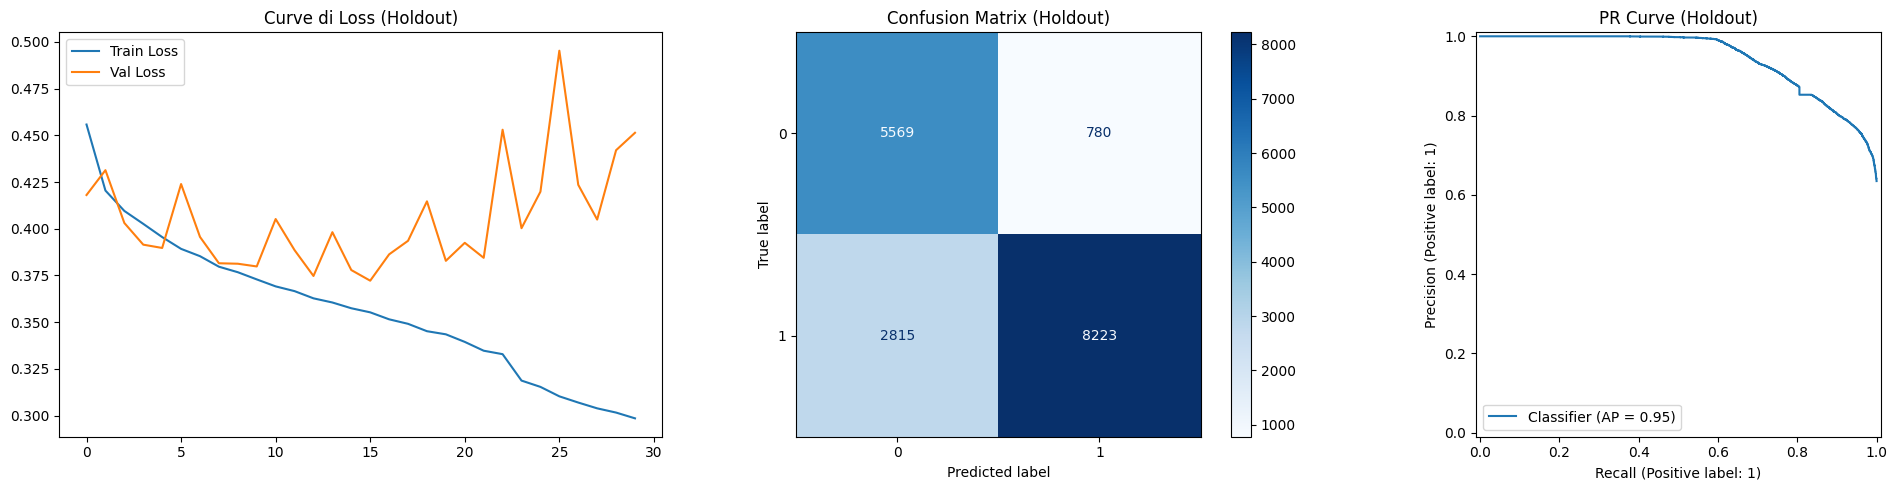

Holdout Macro F1: 0.7883 | Accuracy: 0.7932

--- Classification Report (Holdout) ---
              precision    recall  f1-score   support

      HC (0)       0.66      0.88      0.76      6349
     IBD (1)       0.91      0.74      0.82     11038

    accuracy                           0.79     17387
   macro avg       0.79      0.81      0.79     17387
weighted avg       0.82      0.79      0.80     17387



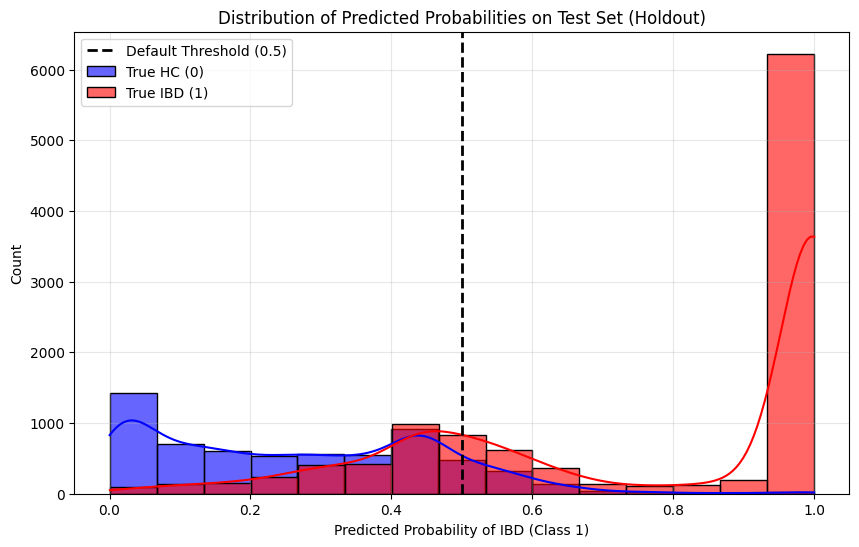

In [6]:
# --- CELLA 6: ESECUZIONE HOLDOUT E GRAFICI ---
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import os

print("="*40)
print("=== FASE 1: ADDESTRAMENTO HOLDOUT ===")
print("="*40)

report_dir = os.path.join(output_dir, "report")
os.makedirs(report_dir, exist_ok=True)

model_ho = build_model()
best_state_ho, history_ho, best_f1_ho = train_one(model_ho, train_loader_ho, val_loader_ho, Y_data[split_ho.idx_train], config, device)
model_ho.load_state_dict(best_state_ho)
torch.save(model_ho.state_dict(), os.path.join(output_dir, "best_weights_holdout.pth"))

preds_test_ho, labels_test_ho, probs_test_ho, test_loss_ho = evaluate_model(model_ho, test_loader_ho, device)
cm_ho = confusion_matrix(labels_test_ho, preds_test_ho)

# 1x3 includendo Precision-Recall
fig, ax = plt.subplots(1, 3, figsize=(20, 5))
ax[0].plot(history_ho["train_loss"], label="Train Loss")
ax[0].plot(history_ho["val_loss"], label="Val Loss")
ax[0].set_title("Curve di Loss (Holdout)")
ax[0].legend()

ConfusionMatrixDisplay(cm_ho).plot(ax=ax[1], cmap="Blues")
ax[1].set_title("Confusion Matrix (Holdout)")

if len(np.unique(labels_test_ho)) > 1:
    PrecisionRecallDisplay.from_predictions(labels_test_ho, probs_test_ho, ax=ax[2])
    ax[2].set_title("PR Curve (Holdout)")
else:
    ax[2].text(0.5, 0.5, "Solo 1 classe", ha='center')

plt.tight_layout()
plt.savefig(os.path.join(report_dir, "fig_metrics_holdout.png"))
plt.show()

ho_acc = accuracy_score(labels_test_ho, preds_test_ho)
ho_f1 = f1_score(labels_test_ho, preds_test_ho, average="macro")
print(f"Holdout Macro F1: {ho_f1:.4f} | Accuracy: {ho_acc:.4f}")
print("\n--- Classification Report (Holdout) ---")
print(classification_report(labels_test_ho, preds_test_ho, target_names=["HC (0)", "IBD (1)"]))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(probs_test_ho[labels_test_ho == 0], bins=15, color='blue', alpha=0.6, label='True HC (0)', kde=True)
sns.histplot(probs_test_ho[labels_test_ho == 1], bins=15, color='red', alpha=0.6, label='True IBD (1)', kde=True)
plt.axvline(0.5, color='k', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities on Test Set (Holdout)')
plt.xlabel('Predicted Probability of IBD (Class 1)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(report_dir, "fig_prob_dist_holdout.png"))
plt.show()



=== FASE 2: ADDESTRAMENTO LOMO ===



--- Running lomo_group_1.0 ---


Epoch    18: reducing learning rate of group 0 to 2.5000e-04.


Epoch    38: reducing learning rate of group 0 to 1.2500e-04.


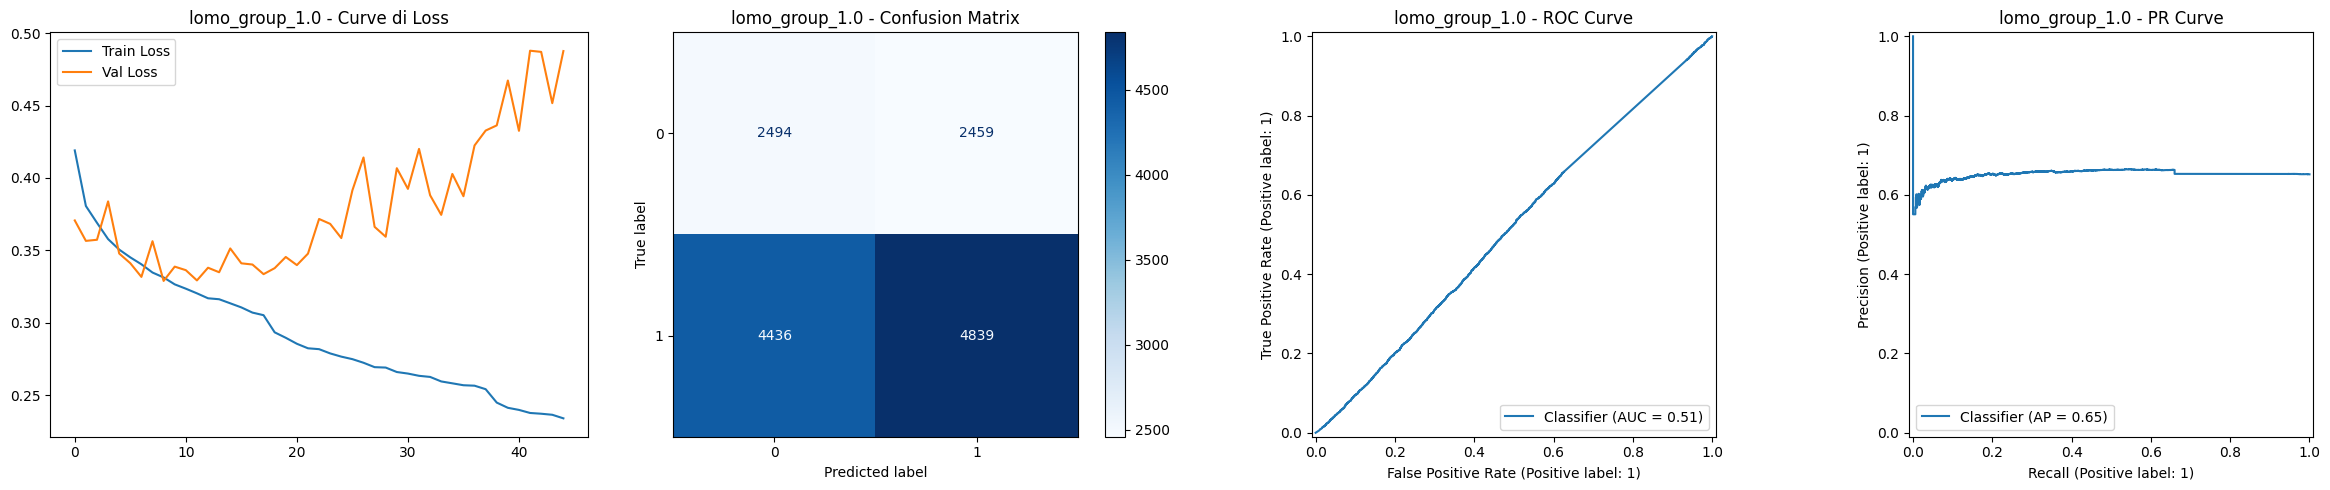


--- Running lomo_group_2.0 ---


Epoch    14: reducing learning rate of group 0 to 2.5000e-04.


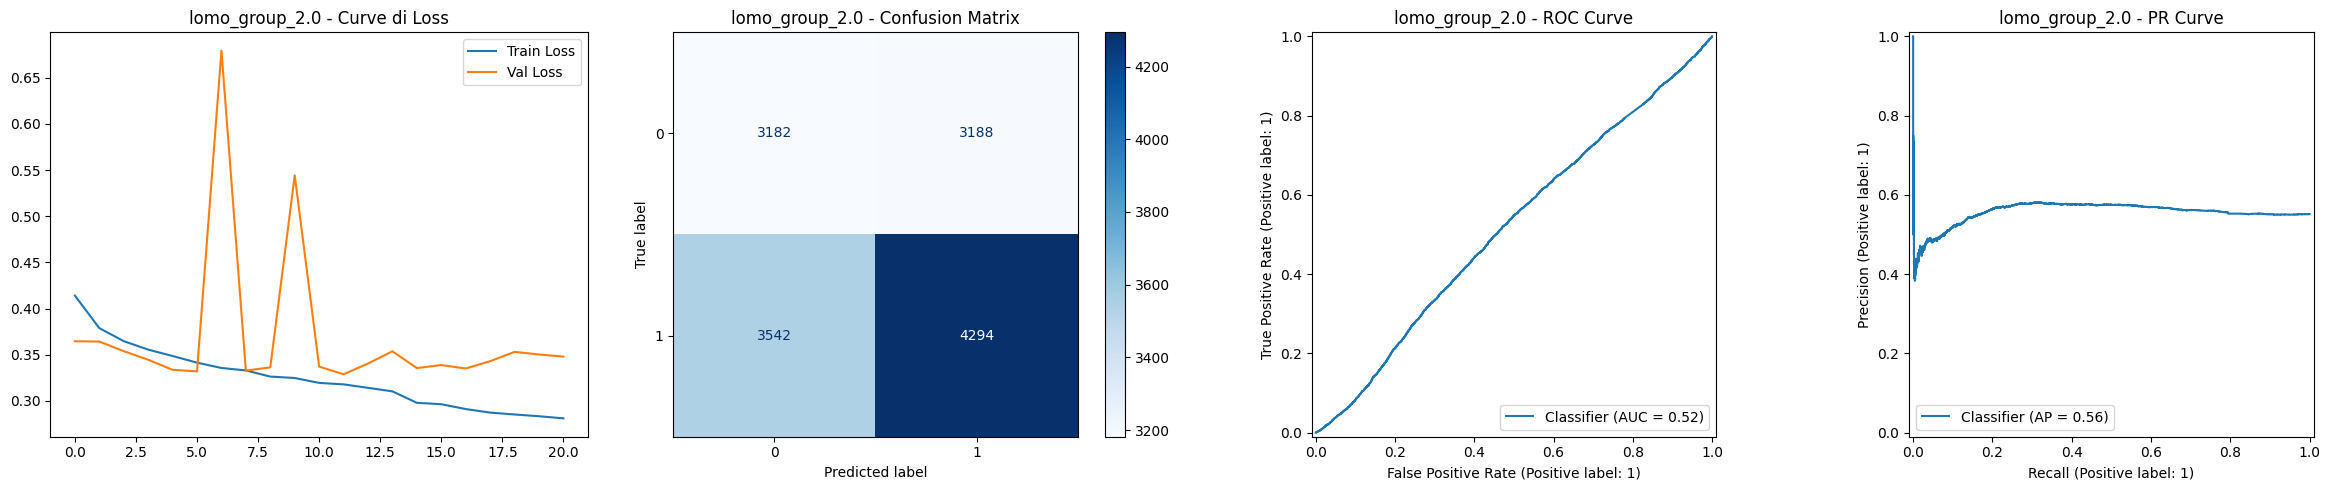


--- Running lomo_group_7.0 ---


Epoch    20: reducing learning rate of group 0 to 2.5000e-04.


Epoch    47: reducing learning rate of group 0 to 1.2500e-04.


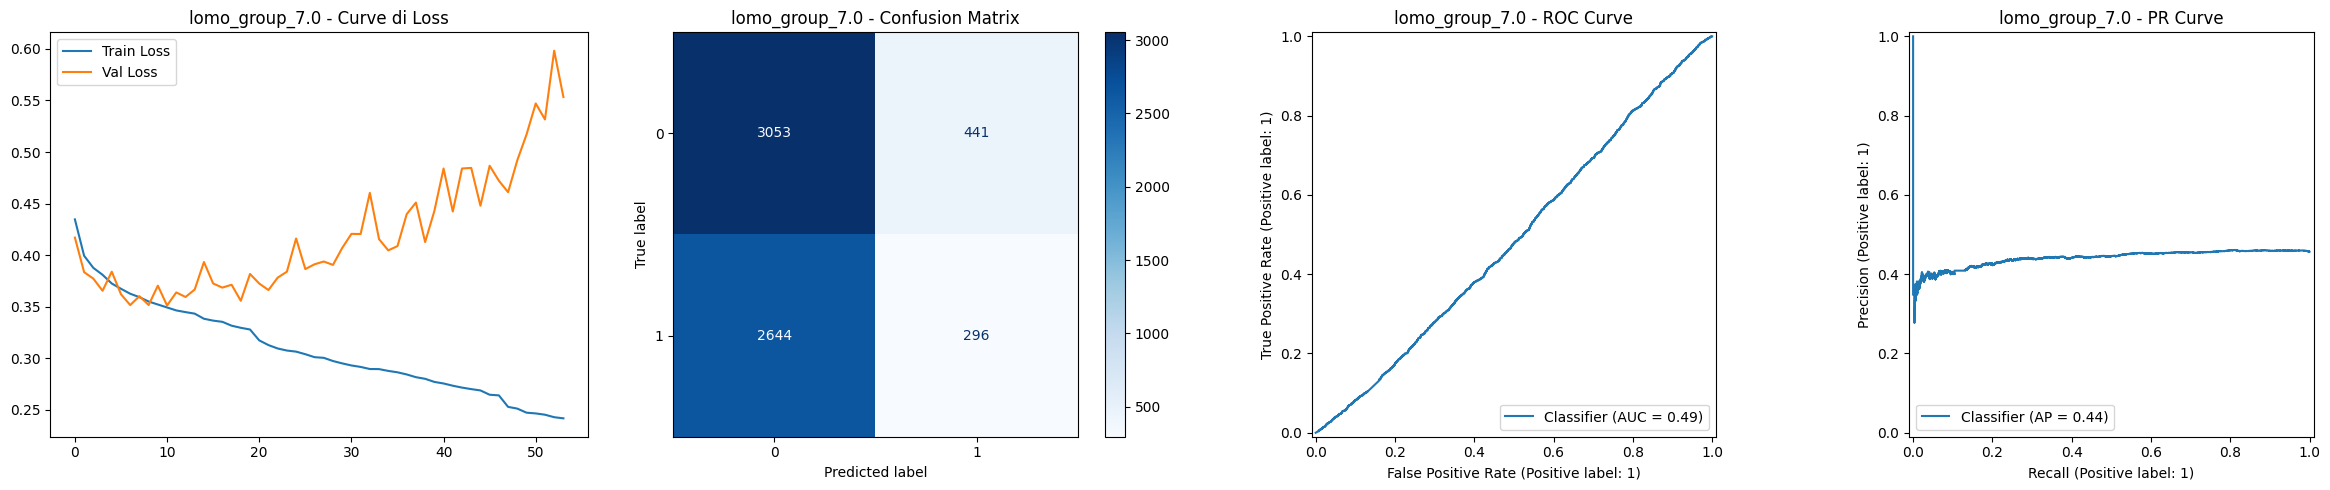


--- Running lomo_group_8.0 ---


Epoch    33: reducing learning rate of group 0 to 2.5000e-04.


Epoch    49: reducing learning rate of group 0 to 1.2500e-04.


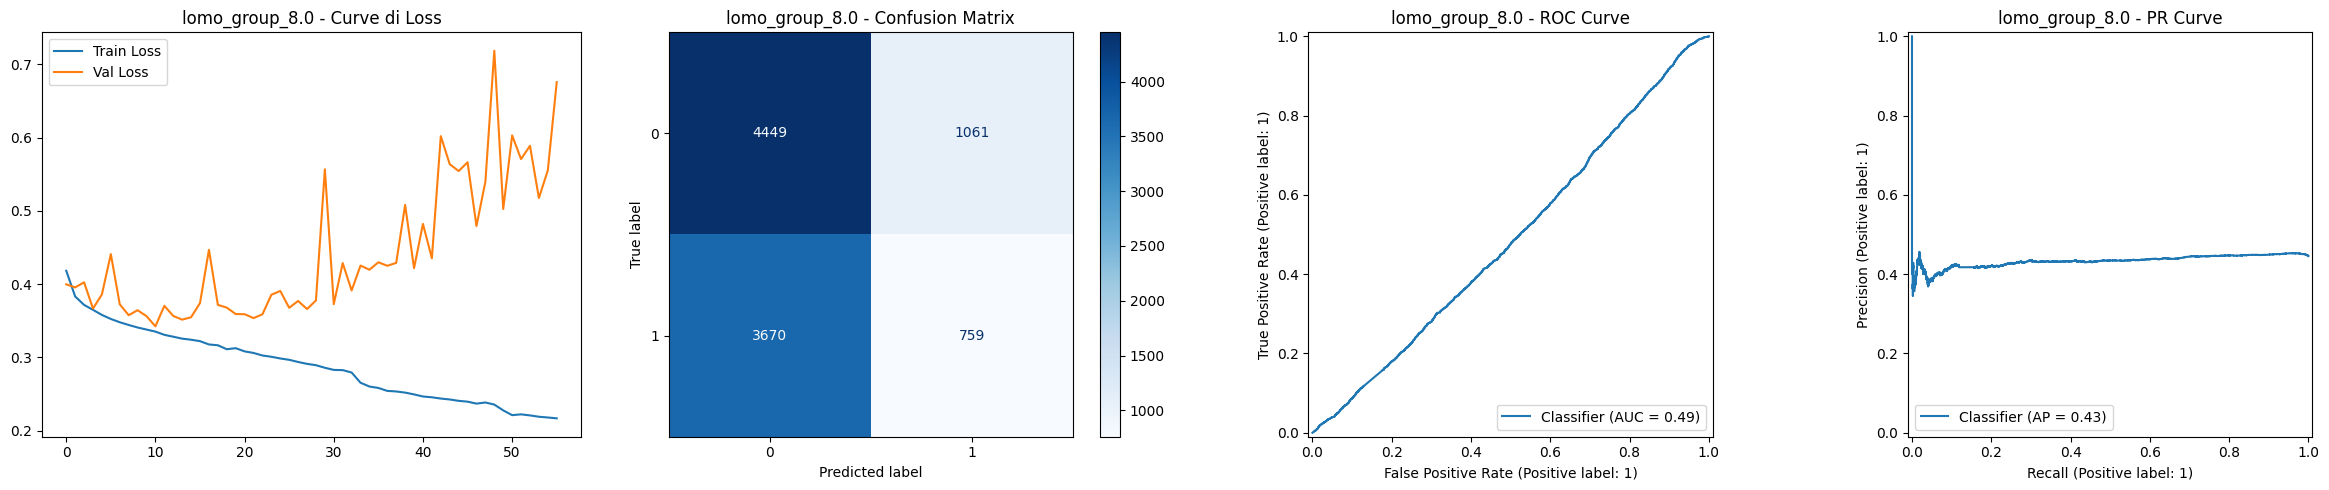


--- Running lomo_group_9.0 ---


Epoch    22: reducing learning rate of group 0 to 2.5000e-04.


Epoch    37: reducing learning rate of group 0 to 1.2500e-04.


Epoch    57: reducing learning rate of group 0 to 6.2500e-05.


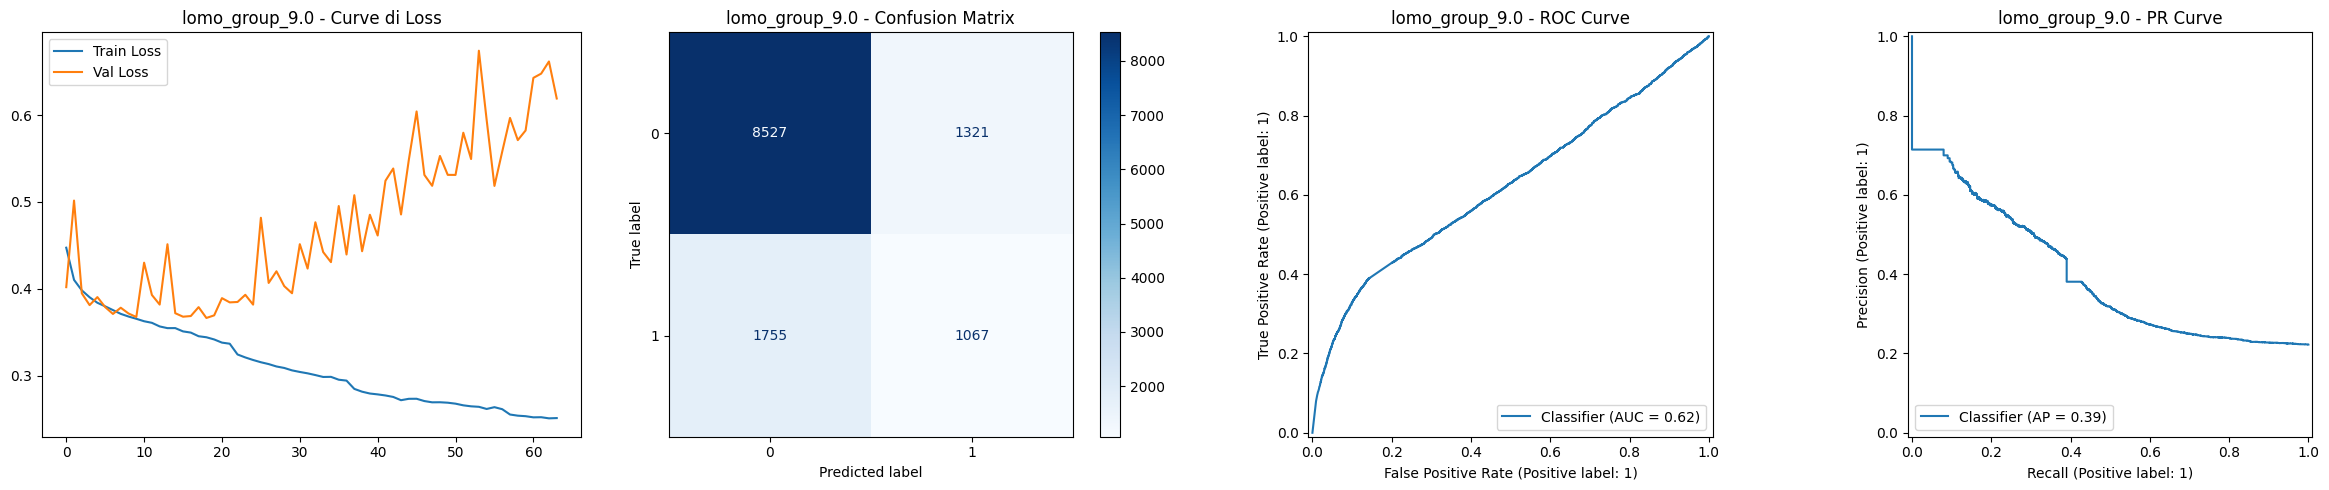


--- Running lomo_group_10.0 ---


Epoch    41: reducing learning rate of group 0 to 2.5000e-04.


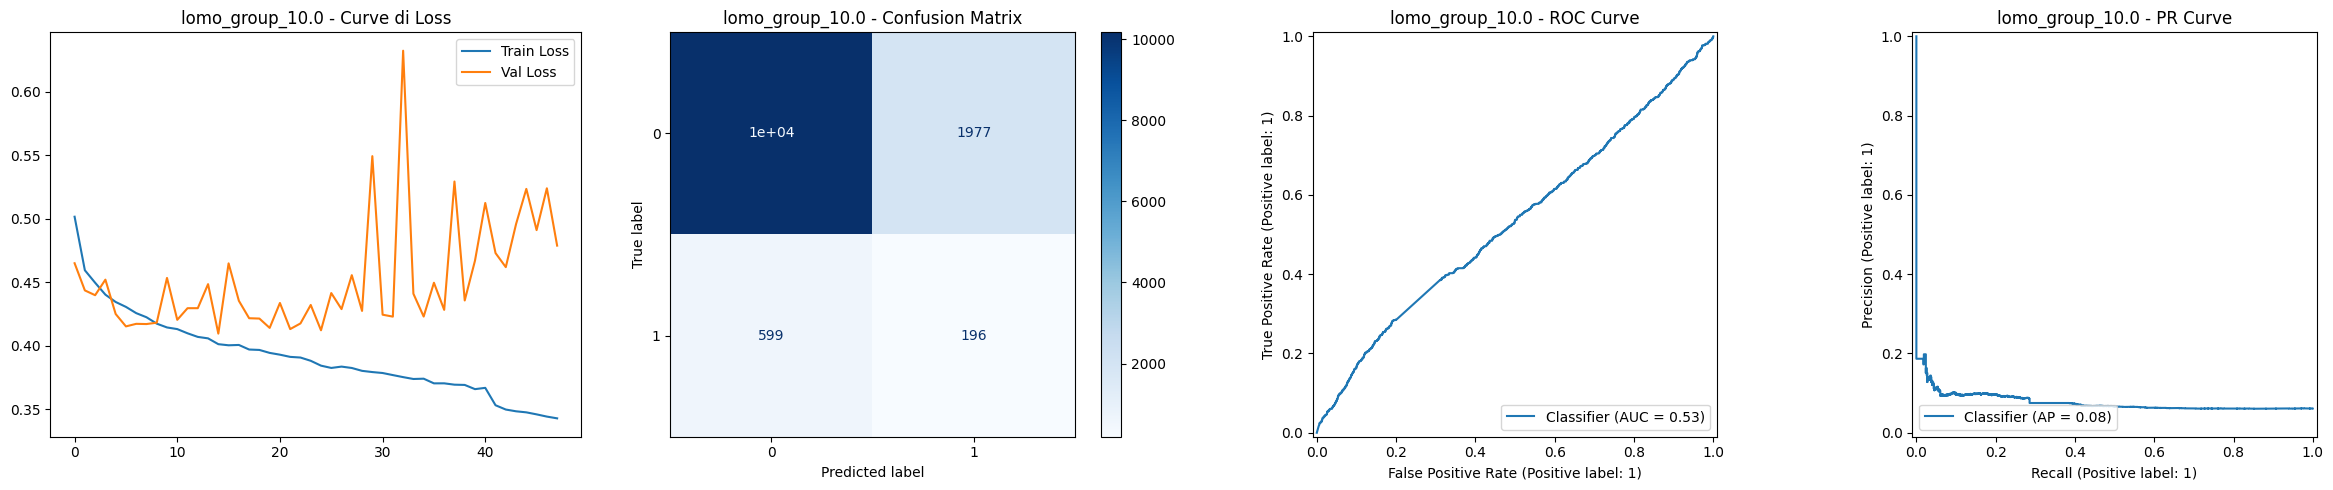


--- RISULTATI PER FOLD ---
           fold  macro_f1  accuracy  roc_auc   pr_auc
 lomo_group_1.0  0.501861  0.515392 0.512108 0.651754
 lomo_group_2.0  0.523336  0.526257 0.518344 0.555443
 lomo_group_7.0  0.412673  0.520516 0.488470 0.441082
 lomo_group_8.0  0.447896  0.523996 0.490038 0.433421
 lomo_group_9.0  0.628395  0.757222 0.622536 0.393697
lomo_group_10.0  0.509832  0.800958 0.531098 0.076946

--- RISULTATI AGGREGATI LOMO (MEDIA ± STD) ---
Macro F1: 0.5040 ± 0.0675
Accuracy: 0.6074 ± 0.1221
ROC AUC:  0.5271 ± 0.0453

--- Classification Report Aggregato (LOMO) ---
              precision    recall  f1-score   support

      HC (0)       0.66      0.75      0.70     42322
     IBD (1)       0.52      0.41      0.46     28097

    accuracy                           0.62     70419
   macro avg       0.59      0.58      0.58     70419
weighted avg       0.60      0.62      0.60     70419



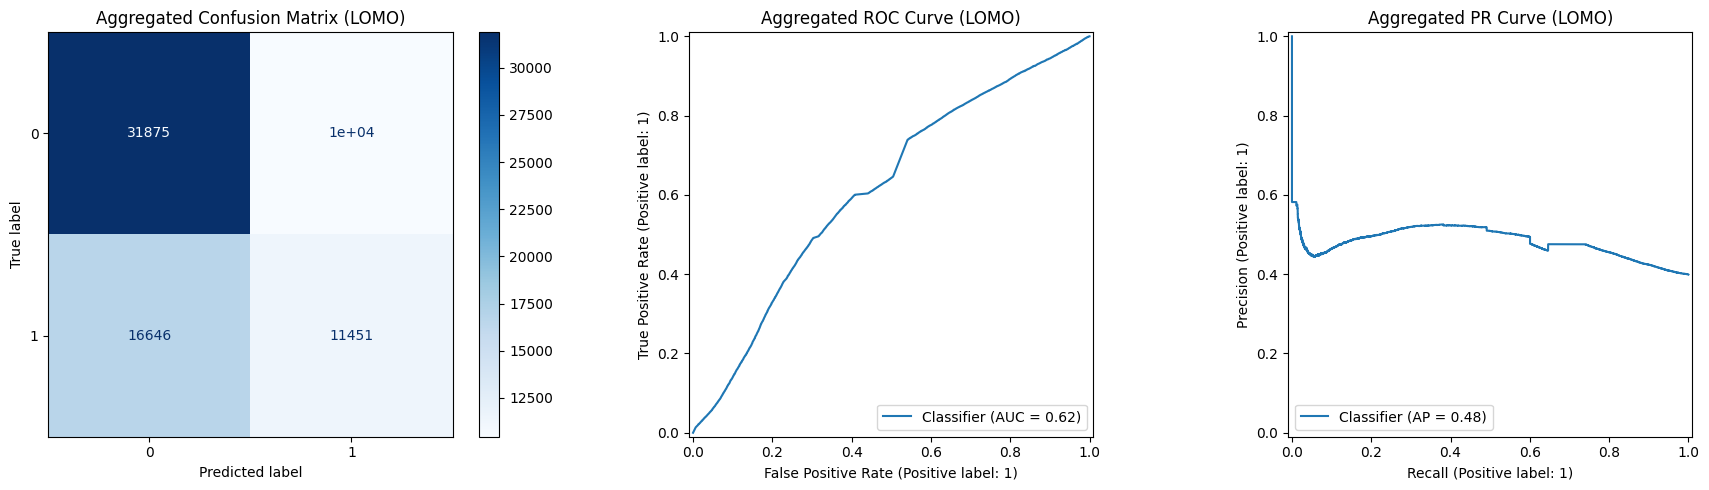

✅ Addestramento Congiunto Completato!


In [7]:
# --- CELLA 7: ESECUZIONE K-FOLD E GRAFICI ---
import math
import pandas as pd
from src.utils.plotting import plot_fold_metrics, plot_aggregated_metrics

print("\n" + "="*40)
print(f"=== FASE 2: ADDESTRAMENTO {config.get('split', {}).get('scheme', 'kfold').upper()} ===")
print("="*40)

folds_dir = os.path.join(output_dir, "kfolds")
os.makedirs(folds_dir, exist_ok=True)
    
CV_RESULTS, all_labels, all_preds, all_probs = [], [], [], []
kf_histories = {}

for i, fold in enumerate(CV_FOLDS, start=1):
    fold_dir = os.path.join(folds_dir, fold.name)
    os.makedirs(fold_dir, exist_ok=True)
    
    y_train, y_val, y_test = Y_data[fold.idx_train], Y_data[fold.idx_val], Y_data[fold.idx_test]
    train_loader = DataLoader(TensorDataset(torch.from_numpy(X_data[fold.idx_train]).unsqueeze(1).float(), torch.from_numpy(y_train)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.from_numpy(X_data[fold.idx_val]).unsqueeze(1).float(), torch.from_numpy(y_val)), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(TensorDataset(torch.from_numpy(X_data[fold.idx_test]).unsqueeze(1).float(), torch.from_numpy(y_test)), batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"\n--- Running {fold.name} ---")
    model_kf = build_model()
    best_state_kf, history_kf, best_val_f1_kf = train_one(model_kf, train_loader, val_loader, y_train, config, device)
    model_kf.load_state_dict(best_state_kf)
    kf_histories[fold.name] = history_kf
    
    torch.save(model_kf.state_dict(), os.path.join(fold_dir, "best_weights.pth"))
    preds_test, labels_test, probs_test, test_loss = evaluate_model(model_kf, test_loader, device)
    
    test_acc = accuracy_score(labels_test, preds_test)
    test_f1 = f1_score(labels_test, preds_test, average="macro")
    test_auc = roc_auc_score(labels_test, probs_test) if len(np.unique(labels_test)) > 1 else None
    
    from sklearn.metrics import average_precision_score
    test_pr_auc = average_precision_score(labels_test, probs_test) if len(np.unique(labels_test)) > 1 else None
    
    metrics = {"fold": fold.name, "macro_f1": float(test_f1), "accuracy": float(test_acc), "roc_auc": float(test_auc) if test_auc is not None else "N/A", "pr_auc": float(test_pr_auc) if test_pr_auc is not None else "N/A"}

    # Niente dump inutili in JSON! Solo tracking in memoria
    
    CV_RESULTS.append(metrics)
    all_labels.append(labels_test)
    all_preds.append(preds_test)
    all_probs.append(probs_test)

    # PLOT SINGOLO FOLD usando utility function
    fig_path = os.path.join(report_dir, f"fig_{fold.name}_metrics.png")
    plot_fold_metrics(history_kf, labels_test, preds_test, probs_test, fold.name, save_path=fig_path)

# METRICHE FINALI K-FOLD
df = pd.DataFrame(CV_RESULTS)
print("\n--- RISULTATI PER FOLD ---")
print(df.to_string(index=False))

f1s = [m["macro_f1"] for m in CV_RESULTS]
accs = [m["accuracy"] for m in CV_RESULTS]
aucs = [float(m["roc_auc"]) for m in CV_RESULTS if m["roc_auc"] != "N/A"]

summary = {
    "mean": {"accuracy": np.mean(accs), "macro_f1": np.mean(f1s), "roc_auc": np.mean(aucs) if len(aucs) else None},
    "std": {"accuracy": np.std(accs), "macro_f1": np.std(f1s), "roc_auc": np.std(aucs) if len(aucs) else None}
}

scheme_name = config.get('split', {}).get('scheme', 'kfold').upper()
print(f"\n--- RISULTATI AGGREGATI {scheme_name} (MEDIA ± STD) ---")
print(f"Macro F1: {summary['mean']['macro_f1']:.4f} ± {summary['std']['macro_f1']:.4f}")
print(f"Accuracy: {summary['mean']['accuracy']:.4f} ± {summary['std']['accuracy']:.4f}")
if summary['mean']['roc_auc']: print(f"ROC AUC:  {summary['mean']['roc_auc']:.4f} ± {summary['std']['roc_auc']:.4f}")

labels_all = np.concatenate(all_labels)
preds_all = np.concatenate(all_preds)
probs_all = np.concatenate(all_probs)

print(f"\n--- Classification Report Aggregato ({scheme_name}) ---")
print(classification_report(labels_all, preds_all, target_names=["HC (0)", "IBD (1)"]))

# GRAFICHE AGGREGATE usando utility function
agg_fig_path = os.path.join(report_dir, "fig_kfold_global_metrics.png")
plot_aggregated_metrics(labels_all, preds_all, probs_all, scheme_name, save_path=agg_fig_path)

print("✅ Addestramento Congiunto Completato!")
